In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import sklearn


In [64]:
image_as_array = mpimg.imread('image-cropped-8x10.jpg')
image_as_array

array([[[254, 255, 255],
        [237, 238, 240],
        [231, 232, 234],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 255, 255],
        [237, 238, 240],
        [231, 232, 234],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 255, 255],
        [237, 238, 240],
        [230, 231, 233],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[253, 253, 253],
        [253, 253, 253],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [65]:
image_as_array.shape

(503, 406, 3)

In [66]:
(h,w,c) = image_as_array.shape
reshaped_image = image_as_array.reshape(h*w,c)
reshaped_image.shape

(204218, 3)

(503, 406)


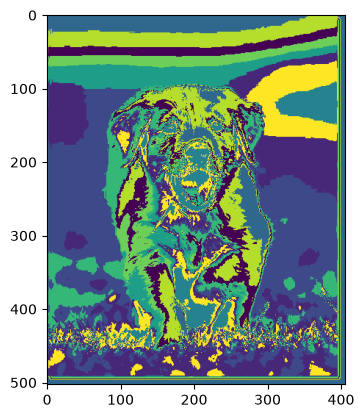

In [67]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=10, random_state=42)
labels = model.fit_predict(reshaped_image)


quantized_image = labels.reshape(h,w)
print(quantized_image.shape)

plt.imshow(quantized_image)


In [68]:
rgb_codes = model.cluster_centers_.round(0).astype(int)
rgb_codes

array([[205, 197, 190],
       [157, 138,  89],
       [175, 160, 106],
       [241, 239, 239],
       [ 81,  63,  34],
       [156, 147, 134],
       [192, 174, 136],
       [176, 173, 172],
       [225, 220, 216],
       [125, 103,  62]])

In [69]:
rgb_codes[labels]


array([[241, 239, 239],
       [241, 239, 239],
       [241, 239, 239],
       ...,
       [241, 239, 239],
       [241, 239, 239],
       [241, 239, 239]], shape=(204218, 3))

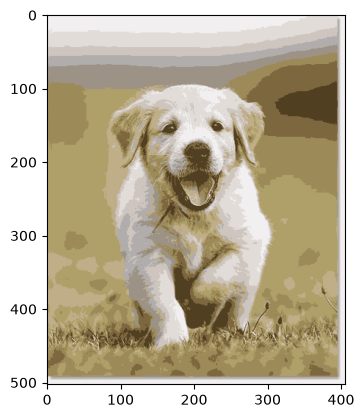

In [70]:
quantized_image = np.array(rgb_codes[labels].reshape(h,w,c))
plt.imshow(quantized_image)